In [2]:
import os, re, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Configuration — All Hyper-parameters in One Place

In [3]:
class CFG:
    # ── Data ─────────────────────────────────────────────────────────────────
    DATA_PATH   = '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv'
    SAMPLE_SIZE = 400_000        # 200k per class  — increase for better acc
    TEST_SIZE   = 0.10           # 10% test
    VAL_SIZE    = 0.10           # 10% validation  (from train)

    # ── BiLSTM ───────────────────────────────────────────────────────────────
    VOCAB_SIZE    = 30_000
    EMB_DIM       = 100          # matches GloVe Twitter 100d
    HIDDEN_DIM    = 256
    NUM_LAYERS    = 3
    DROPOUT       = 0.4
    MAX_LEN_LSTM  = 50
    BATCH_LSTM    = 512
    EPOCHS_LSTM   = 15
    LR_LSTM       = 3e-4

    # ── BERT ─────────────────────────────────────────────────────────────────
    BERT_MODEL    = 'distilbert-base-uncased'   # lighter than bert-base, still strong
    MAX_LEN_BERT  = 64
    BATCH_BERT    = 64
    EPOCHS_BERT   = 4
    LR_BERT       = 2e-5
    WARMUP_RATIO  = 0.1
    GRAD_CLIP     = 1.0

    # ── Ensemble ─────────────────────────────────────────────────────────────
    BERT_WEIGHT   = 0.65
    LSTM_WEIGHT   = 0.35

    # ── Paths ─────────────────────────────────────────────────────────────────
    GLOVE_PATH    = '/kaggle/input/datasets/yacharki/glove-twitter-27b-25d-50d-100d-200d-42b-300d/glove.twitter.27B.100d.txt'
    SAVE_DIR      = '/kaggle/working/'

print('Config loaded ✓')

Config loaded ✓


## 3. Data Loading & EDA

In [4]:
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df_full = pd.read_csv(CFG.DATA_PATH, encoding='ISO-8859-1', names=columns)
df_full = df_full[['text', 'target']]
df_full['target'] = df_full['target'].replace(4, 1)

print(f'Full dataset : {len(df_full):,} rows')
print(df_full['target'].value_counts())

# Balanced downsample
half = CFG.SAMPLE_SIZE // 2
df = pd.concat([
    df_full[df_full['target'] == 0].sample(half, random_state=SEED),
    df_full[df_full['target'] == 1].sample(half, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\nWorking sample: {len(df):,} rows')
print(df['target'].value_counts())

Full dataset : 1,600,000 rows
target
0    800000
1    800000
Name: count, dtype: int64

Working sample: 400,000 rows
target
0    200000
1    200000
Name: count, dtype: int64


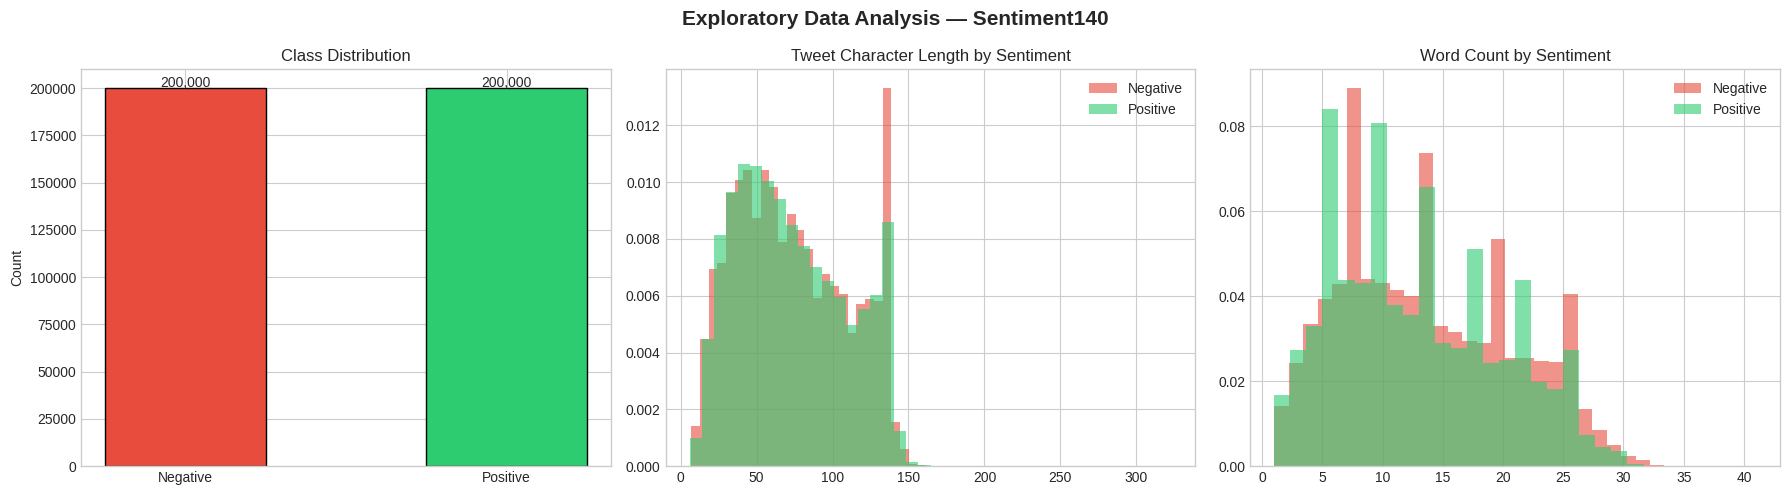

EDA complete ✓


In [5]:
# ── EDA Visualizations ───────────────────────────────────────────────────────
df['text_len'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis — Sentiment140', fontsize=15, fontweight='bold')

# Class distribution
axes[0].bar(['Negative', 'Positive'], df['target'].value_counts().values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, df['target'].value_counts().values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10)

# Text length distribution by class
for label, color, name in [(0, '#e74c3c', 'Negative'), (1, '#2ecc71', 'Positive')]:
    axes[1].hist(df[df['target']==label]['text_len'], bins=40, alpha=0.6,
                 color=color, label=name, density=True)
axes[1].set_title('Tweet Character Length by Sentiment')
axes[1].legend()

# Word count distribution
for label, color, name in [(0, '#e74c3c', 'Negative'), (1, '#2ecc71', 'Positive')]:
    axes[2].hist(df[df['target']==label]['word_count'], bins=30, alpha=0.6,
                 color=color, label=name, density=True)
axes[2].set_title('Word Count by Sentiment')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete ✓')

## 4. Advanced Text Preprocessing

In [6]:
# Emoticon → sentiment word mapping
EMOTICONS = {
    ':)': ' happy ', ':-)': ' happy ', '=)': ' happy ', ':D': ' happy ',
    ':(': ' sad ', ':-(': ' sad ', ":'(": ' sad ',
    ';)': ' wink ', '<3': ' love ', '</3': ' heartbroken ',
    ':P': ' playful ', ':p': ' playful ', ':O': ' surprised ',
    ':@': ' angry ', '>:(': ' angry '
}

# Common Twitter contractions
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'ve": " have", "'ll": " will",
    "'d": " would", "'m": " am", "it's": "it is",
    "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "we're": "we are",
    "they're": "they are", "he's": "he is", "she's": "she is"
}

STOP_WORDS = stopwords.words('english')
# Keep negation words — critical for sentiment!
KEEP_WORDS = {'no', 'not', 'nor', 'never', 'neither', "n't", 'nothing',
               'nobody', 'nowhere', 'none', 'cannot'}
STOP_WORDS = set(STOP_WORDS) - KEEP_WORDS

def preprocess(text: str) -> str:
    """Advanced tweet cleaning with emoticon & negation preservation."""
    text = text.lower()

    # Replace emoticons before stripping punctuation
    for emot, repl in EMOTICONS.items():
        text = text.replace(emot, repl)

    # Expand contractions
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)

    # Remove URLs, mentions, hashtag symbols (keep hashtag text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove numbers and special chars, keep letters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Collapse repeated characters: 'looooove' → 'loove' (keep 2 for emphasis)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Remove stopwords (preserving negation)
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]

    return ' '.join(tokens)

# Apply preprocessing
print('Preprocessing tweets...')
t0 = time.time()
df['cleaned'] = df['text'].apply(preprocess)
print(f'Done in {time.time()-t0:.1f}s ✓')

# Show examples
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"\nOriginal : {row['text']}")
    print(f"Cleaned  : {row['cleaned']}")
    print(f"Sentiment: {'Positive' if row['target'] else 'Negative'}")

Preprocessing tweets...
Done in 6.6s ✓

Original : Home from the movies/dinner with Jack, George and Ella.. now off to sleep, wake up in six hours 
Cleaned  : home movies dinner jack george ella sleep wake six hours
Sentiment: Negative

Original : @mjh81 I'm sorry  Please accept this combo as an apology: http://bit.ly/2P98v
Cleaned  : sorry please accept combo apology
Sentiment: Negative

Original : @NikkiLav Woop. Good stuff. I am in a hunt for a job.  Rather depressing trying to find a job TBH.
Cleaned  : woop good stuff hunt job rather depressing trying find job tbh
Sentiment: Negative


## 5. Train / Val / Test Split

In [7]:
X = df['cleaned'].values
y = df['target'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CFG.TEST_SIZE, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
    random_state=SEED, stratify=y_train_full
)

print(f'Train : {len(X_train):>7,}')
print(f'Val   : {len(X_val):>7,}')
print(f'Test  : {len(X_test):>7,}')

Train : 320,000
Val   :  40,000
Test  :  40,000


## 6. BiLSTM with Multi-Head Attention

In [8]:
# ── 6.1  Build Vocabulary ─────────────────────────────────────────────────────
all_words = ' '.join(X_train).split()
word_freq = Counter(all_words)
most_common = word_freq.most_common(CFG.VOCAB_SIZE - 2)  # reserve PAD + UNK

vocab = {'<PAD>': 0, '<UNK>': 1}
vocab.update({w: i + 2 for i, (w, _) in enumerate(most_common)})
idx2word = {v: k for k, v in vocab.items()}

print(f'Vocabulary size: {len(vocab):,}')

Vocabulary size: 30,000


In [9]:
# ── 6.2  Load GloVe Twitter Embeddings ───────────────────────────────────────
def load_glove(path, vocab, emb_dim):
    """Load pre-trained GloVe vectors for words in vocab."""
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab), emb_dim)).astype('float32')
    embeddings[0] = 0  # PAD → zeros
    found = 0
    if not os.path.exists(path):
        print(f'⚠  GloVe not found at {path}. Using random embeddings.')
        print('   Add the GloVe Twitter dataset to Kaggle for a boost!')
        return embeddings
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split()
            word = parts[0]
            if word in vocab:
                embeddings[vocab[word]] = np.array(parts[1:], dtype='float32')
                found += 1
    print(f'GloVe coverage: {found}/{len(vocab)} words ({found/len(vocab)*100:.1f}%)')
    return embeddings

glove_matrix = load_glove(CFG.GLOVE_PATH, vocab, CFG.EMB_DIM)

GloVe coverage: 29298/30000 words (97.7%)


In [10]:
# ── 6.3  Dataset & Collate ────────────────────────────────────────────────────
def encode(text, vocab, max_len):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    return ids

class TweetDatasetLSTM(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.data   = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels

    def __len__(self):  return len(self.data)

    def __getitem__(self, i):
        ids = self.data[i] or [1]  # avoid empty
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)


def collate_lstm(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, torch.stack(labels), lengths


train_ds_lstm = TweetDatasetLSTM(X_train, y_train, vocab, CFG.MAX_LEN_LSTM)
val_ds_lstm   = TweetDatasetLSTM(X_val,   y_val,   vocab, CFG.MAX_LEN_LSTM)
test_ds_lstm  = TweetDatasetLSTM(X_test,  y_test,  vocab, CFG.MAX_LEN_LSTM)

train_loader_lstm = DataLoader(train_ds_lstm, batch_size=CFG.BATCH_LSTM,
                               shuffle=True,  collate_fn=collate_lstm,
                               num_workers=2, pin_memory=True)
val_loader_lstm   = DataLoader(val_ds_lstm,   batch_size=CFG.BATCH_LSTM*2,
                               shuffle=False, collate_fn=collate_lstm, num_workers=2)
test_loader_lstm  = DataLoader(test_ds_lstm,  batch_size=CFG.BATCH_LSTM*2,
                               shuffle=False, collate_fn=collate_lstm, num_workers=2)
print('LSTM data loaders ready ✓')

LSTM data loaders ready ✓


In [12]:
# ── 6.5  Training Loop ────────────────────────────────────────────────────────
def evaluate_lstm(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x, lengths)
            probs  = F.softmax(logits, dim=-1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc, np.array(all_probs), np.array(all_preds)


optimizer_lstm = optim.AdamW(lstm_model.parameters(), lr=CFG.LR_LSTM, weight_decay=1e-4)
criterion      = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler_lstm = optim.lr_scheduler.CosineAnnealingLR(optimizer_lstm, T_max=CFG.EPOCHS_LSTM)

best_val_acc_lstm  = 0
lstm_history       = {'train_loss': [], 'val_acc': [], 'val_auc': []}
patience, bad_epochs = 3, 0

print('Training BiLSTM...')
print('-' * 55)

for epoch in range(1, CFG.EPOCHS_LSTM + 1):
    lstm_model.train()
    total_loss = 0

    for x, y, lengths in train_loader_lstm:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer_lstm.zero_grad(set_to_none=True)
        logits, _ = lstm_model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer_lstm.step()
        total_loss += loss.item()

    scheduler_lstm.step()
    avg_loss = total_loss / len(train_loader_lstm)
    val_acc, val_auc, _, _ = evaluate_lstm(lstm_model, val_loader_lstm)

    lstm_history['train_loss'].append(avg_loss)
    lstm_history['val_acc'].append(val_acc)
    lstm_history['val_auc'].append(val_auc)

    flag = ''
    if val_acc > best_val_acc_lstm:
        best_val_acc_lstm = val_acc
        torch.save(lstm_model.state_dict(), f'{CFG.SAVE_DIR}best_lstm.pth')
        bad_epochs = 0
        flag = ' ← saved'
    else:
        bad_epochs += 1

    print(f'Ep {epoch:02d}/{CFG.EPOCHS_LSTM} | Loss {avg_loss:.4f} | '
          f'Val Acc {val_acc:.4f} | Val AUC {val_auc:.4f}{flag}')

    if bad_epochs >= patience:
        print('Early stopping triggered.')
        break

# Load best weights
lstm_model.load_state_dict(torch.load(f'{CFG.SAVE_DIR}best_lstm.pth', map_location=DEVICE, weights_only=True))
print(f'\nBest Val Accuracy (LSTM): {best_val_acc_lstm:.4f}')

Training BiLSTM...
-------------------------------------------------------
Ep 01/15 | Loss 0.5133 | Val Acc 0.7863 | Val AUC 0.8730 ← saved
Ep 02/15 | Loss 0.4686 | Val Acc 0.7986 | Val AUC 0.8808 ← saved
Ep 03/15 | Loss 0.4543 | Val Acc 0.8015 | Val AUC 0.8846 ← saved
Ep 04/15 | Loss 0.4438 | Val Acc 0.8048 | Val AUC 0.8875 ← saved
Ep 05/15 | Loss 0.4350 | Val Acc 0.8041 | Val AUC 0.8880
Ep 06/15 | Loss 0.4270 | Val Acc 0.8040 | Val AUC 0.8887
Ep 07/15 | Loss 0.4202 | Val Acc 0.8043 | Val AUC 0.8882
Early stopping triggered.

Best Val Accuracy (LSTM): 0.8048


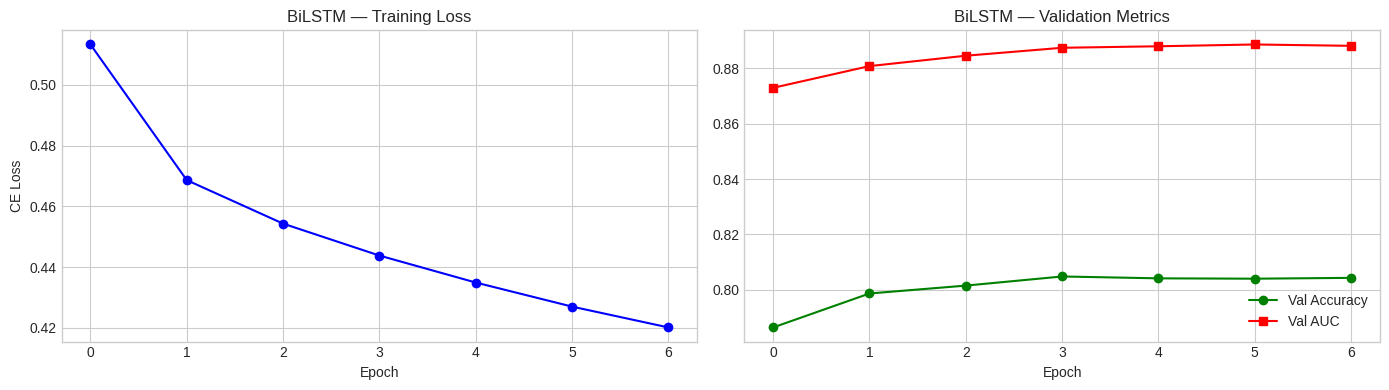

In [13]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(lstm_history['train_loss'], 'b-o', label='Train Loss')
axes[0].set_title('BiLSTM — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[1].plot(lstm_history['val_acc'],  'g-o', label='Val Accuracy')
axes[1].plot(lstm_history['val_auc'],  'r-s', label='Val AUC')
axes[1].set_title('BiLSTM — Validation Metrics')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}lstm_curves.png', dpi=150)
plt.show()

## 7. DistilBERT Fine-Tuning

In [14]:
# ── 7.1  Tokenizer & Dataset ──────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained(CFG.BERT_MODEL)

class TweetDatasetBERT(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return {
            'input_ids'      : self.encodings['input_ids'][i],
            'attention_mask' : self.encodings['attention_mask'][i],
            'labels'         : self.labels[i]
        }


# Use raw (not over-cleaned) text for BERT — it handles punctuation well
def light_clean(text):
    """Minimal cleaning for BERT: just URLs and mentions."""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '@user', text)
    return text.strip()

# FIX: Reuse the same df split as the LSTM (same indices via df.iloc).
# The LSTM split was done on df['cleaned'] / df['target'] with SEED=42,
# so we recover the matching raw texts using the same positional split.
raw_texts = df['text'].values
raw_y     = df['target'].values

raw_train_full, Xr_test, yr_train_full, yr_test = train_test_split(
    raw_texts, raw_y, test_size=CFG.TEST_SIZE, random_state=SEED, stratify=raw_y)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    raw_train_full, yr_train_full,
    test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
    random_state=SEED, stratify=yr_train_full
)
Xr_train = np.array([light_clean(t) for t in Xr_train])
Xr_val   = np.array([light_clean(t) for t in Xr_val])
Xr_test  = np.array([light_clean(t) for t in Xr_test])

# yr_test now matches y_test (same stratified split from same df, same SEED)
assert len(yr_test) == len(y_test), "Test set size mismatch between LSTM and BERT splits"
assert (np.array(yr_test) == np.array(y_test)).all(), "Test labels mismatch — splits diverged"

print('Tokenizing BERT datasets... (may take ~1 min)')
t0 = time.time()
train_ds_bert = TweetDatasetBERT(Xr_train, yr_train, bert_tokenizer, CFG.MAX_LEN_BERT)
val_ds_bert   = TweetDatasetBERT(Xr_val,   yr_val,   bert_tokenizer, CFG.MAX_LEN_BERT)
test_ds_bert  = TweetDatasetBERT(Xr_test,  yr_test,  bert_tokenizer, CFG.MAX_LEN_BERT)
print(f'Done in {time.time()-t0:.1f}s ✓')

train_loader_bert = DataLoader(train_ds_bert, batch_size=CFG.BATCH_BERT,
                               shuffle=True,  num_workers=2, pin_memory=True)
val_loader_bert   = DataLoader(val_ds_bert,   batch_size=CFG.BATCH_BERT*2,
                               shuffle=False, num_workers=2)
test_loader_bert  = DataLoader(test_ds_bert,  batch_size=CFG.BATCH_BERT*2,
                               shuffle=False, num_workers=2)
print('BERT loaders ready ✓')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing BERT datasets... (may take ~1 min)
Done in 33.9s ✓
BERT loaders ready ✓


In [15]:
# ── 7.2  Model ────────────────────────────────────────────────────────────────
bert_model = AutoModelForSequenceClassification.from_pretrained(
    CFG.BERT_MODEL, num_labels=2
).to(DEVICE)

# Unfreeze all layers (full fine-tuning)
for param in bert_model.parameters():
    param.requires_grad = True

bert_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'DistilBERT params: {bert_params:,}')

2026-04-21 19:00:05.188283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776798005.415773      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776798005.482246      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776798005.995516      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776798005.995563      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776798005.995567      23 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT params: 66,955,010


In [16]:
# ── 7.3  Training Loop ────────────────────────────────────────────────────────
total_steps   = len(train_loader_bert) * CFG.EPOCHS_BERT
warmup_steps  = int(total_steps * CFG.WARMUP_RATIO)

# Layer-wise LR decay: lower LR for lower (more general) layers
no_decay  = ['bias', 'LayerNorm.weight']
param_groups = [
    {'params': [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': 1e-2},
    {'params': [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer_bert = AdamW(param_groups, lr=CFG.LR_BERT, eps=1e-8)
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)


def evaluate_bert(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            outputs   = model(input_ids, attention_mask=attn_mask)
            logits    = outputs.logits
            probs     = F.softmax(logits, dim=-1)[:, 1]
            preds     = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc, np.array(all_probs), np.array(all_preds)


best_val_acc_bert  = 0
bert_bad_epochs    = 0
bert_history       = {'train_loss': [], 'val_acc': [], 'val_auc': []}

print('Training DistilBERT...')
print('-' * 60)

for epoch in range(1, CFG.EPOCHS_BERT + 1):
    bert_model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader_bert):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        optimizer_bert.zero_grad(set_to_none=True)
        outputs = bert_model(input_ids, attention_mask=attn_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), CFG.GRAD_CLIP)
        optimizer_bert.step()
        scheduler_bert.step()
        total_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f'  Step {step+1}/{len(train_loader_bert)} | Loss {total_loss/(step+1):.4f}')

    avg_loss = total_loss / len(train_loader_bert)
    val_acc, val_auc, _, _ = evaluate_bert(bert_model, val_loader_bert)

    bert_history['train_loss'].append(avg_loss)
    bert_history['val_acc'].append(val_acc)
    bert_history['val_auc'].append(val_auc)

    flag = ''
    if val_acc > best_val_acc_bert:
        best_val_acc_bert = val_acc
        torch.save(bert_model.state_dict(), f'{CFG.SAVE_DIR}best_bert.pth')
        bert_bad_epochs = 0
        flag = ' ← saved'
    else:
        bert_bad_epochs += 1

    print(f'Ep {epoch}/{CFG.EPOCHS_BERT} | Loss {avg_loss:.4f} | '
          f'Val Acc {val_acc:.4f} | Val AUC {val_auc:.4f}{flag}')

    if bert_bad_epochs >= 2:
        print('Early stopping triggered (BERT).')
        break

bert_model.load_state_dict(torch.load(f'{CFG.SAVE_DIR}best_bert.pth', map_location=DEVICE, weights_only=True))
print(f'\nBest Val Accuracy (BERT): {best_val_acc_bert:.4f}')

Training DistilBERT...
------------------------------------------------------------
  Step 200/5000 | Loss 0.6846
  Step 400/5000 | Loss 0.6173
  Step 600/5000 | Loss 0.5641
  Step 800/5000 | Loss 0.5324
  Step 1000/5000 | Loss 0.5095
  Step 1200/5000 | Loss 0.4930
  Step 1400/5000 | Loss 0.4803
  Step 1600/5000 | Loss 0.4701
  Step 1800/5000 | Loss 0.4618
  Step 2000/5000 | Loss 0.4546
  Step 2200/5000 | Loss 0.4472
  Step 2400/5000 | Loss 0.4418
  Step 2600/5000 | Loss 0.4367
  Step 2800/5000 | Loss 0.4327
  Step 3000/5000 | Loss 0.4285
  Step 3200/5000 | Loss 0.4246
  Step 3400/5000 | Loss 0.4214
  Step 3600/5000 | Loss 0.4181
  Step 3800/5000 | Loss 0.4152
  Step 4000/5000 | Loss 0.4127
  Step 4200/5000 | Loss 0.4104
  Step 4400/5000 | Loss 0.4079
  Step 4600/5000 | Loss 0.4056
  Step 4800/5000 | Loss 0.4032
  Step 5000/5000 | Loss 0.4009
Ep 1/4 | Loss 0.4009 | Val Acc 0.8490 | Val AUC 0.9294 ← saved
  Step 200/5000 | Loss 0.3141
  Step 400/5000 | Loss 0.3150
  Step 600/5000 | Loss

## 8. Ensemble & Final Evaluation

In [17]:
# ── 8.1  Get test probabilities from both models ──────────────────────────────
print('Getting test predictions...')
lstm_acc, lstm_auc, lstm_probs, lstm_preds = evaluate_lstm(lstm_model, test_loader_lstm)
bert_acc, bert_auc, bert_probs, bert_preds = evaluate_bert(bert_model, test_loader_bert)

# Weighted ensemble — both models evaluated on same test split (y_test == yr_test)
ensemble_probs = CFG.BERT_WEIGHT * bert_probs + CFG.LSTM_WEIGHT * lstm_probs
ensemble_preds = (ensemble_probs >= 0.5).astype(int)
ensemble_acc   = accuracy_score(y_test, ensemble_preds)
ensemble_auc   = roc_auc_score(y_test, ensemble_probs)

print('\n' + '='*60)
print(f'  BiLSTM     Accuracy: {lstm_acc:.4f}  |  AUC: {lstm_auc:.4f}')
print(f'  DistilBERT Accuracy: {bert_acc:.4f}  |  AUC: {bert_auc:.4f}')
print(f'  ENSEMBLE   Accuracy: {ensemble_acc:.4f}  |  AUC: {ensemble_auc:.4f}')
print('='*60)

Getting test predictions...

  BiLSTM     Accuracy: 0.8053  |  AUC: 0.8864
  DistilBERT Accuracy: 0.8550  |  AUC: 0.9316
  ENSEMBLE   Accuracy: 0.8567  |  AUC: 0.9302


In [18]:
# ── 8.2  Detailed Reports ─────────────────────────────────────────────────────
print('\n── BiLSTM ──')
print(classification_report(y_test, lstm_preds, target_names=['Negative', 'Positive']))

print('\n── DistilBERT ──')
print(classification_report(y_test, bert_preds, target_names=['Negative', 'Positive']))

print('\n── Ensemble ──')
print(classification_report(y_test, ensemble_preds, target_names=['Negative', 'Positive']))


── BiLSTM ──
              precision    recall  f1-score   support

    Negative       0.80      0.81      0.81     20000
    Positive       0.81      0.80      0.80     20000

    accuracy                           0.81     40000
   macro avg       0.81      0.81      0.81     40000
weighted avg       0.81      0.81      0.81     40000


── DistilBERT ──
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     20000
    Positive       0.86      0.85      0.85     20000

    accuracy                           0.86     40000
   macro avg       0.86      0.86      0.86     40000
weighted avg       0.86      0.86      0.86     40000


── Ensemble ──
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     20000
    Positive       0.86      0.85      0.86     20000

    accuracy                           0.86     40000
   macro avg       0.86      0.86      0.86     40000
weighted avg       0.86   

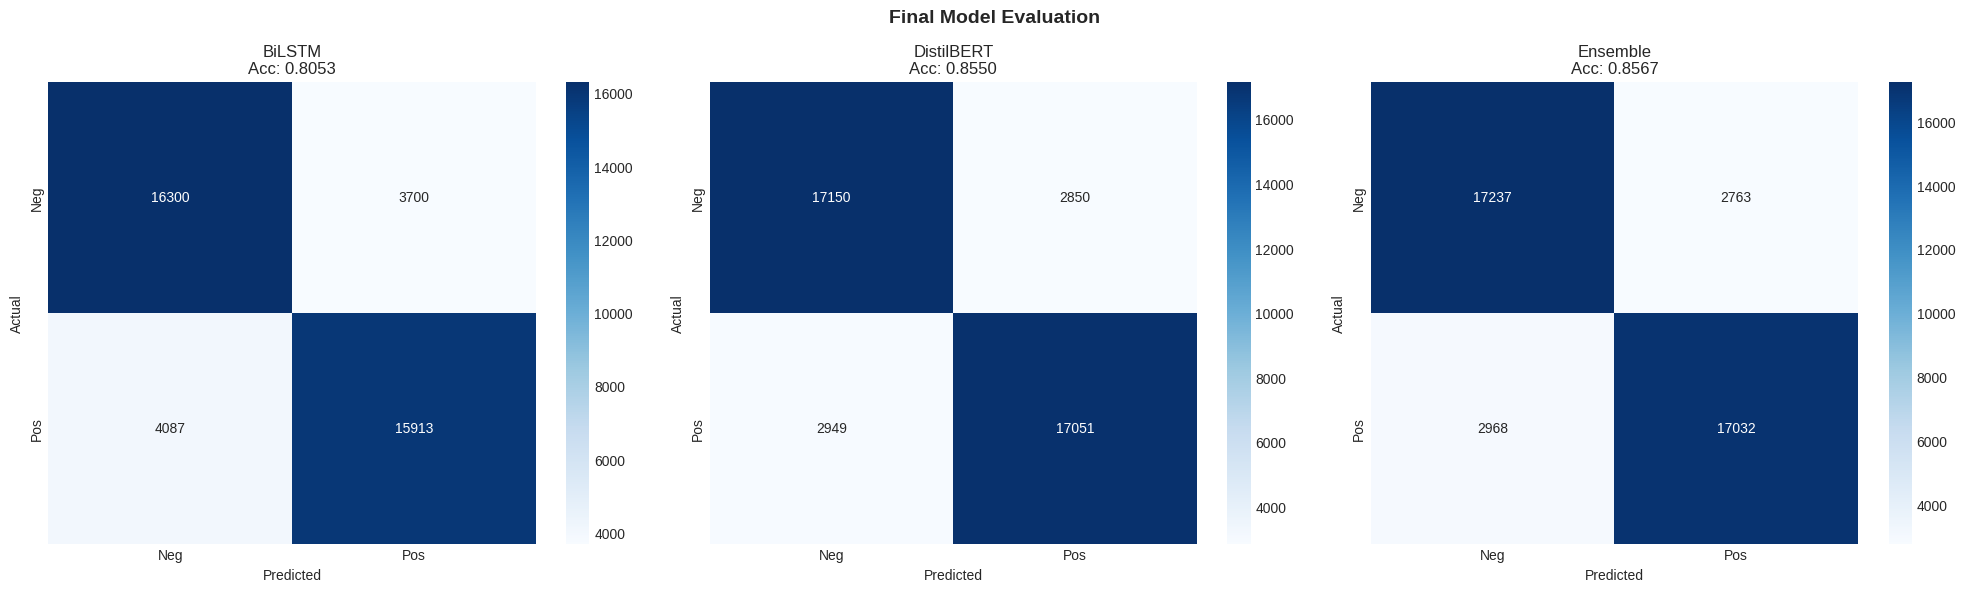

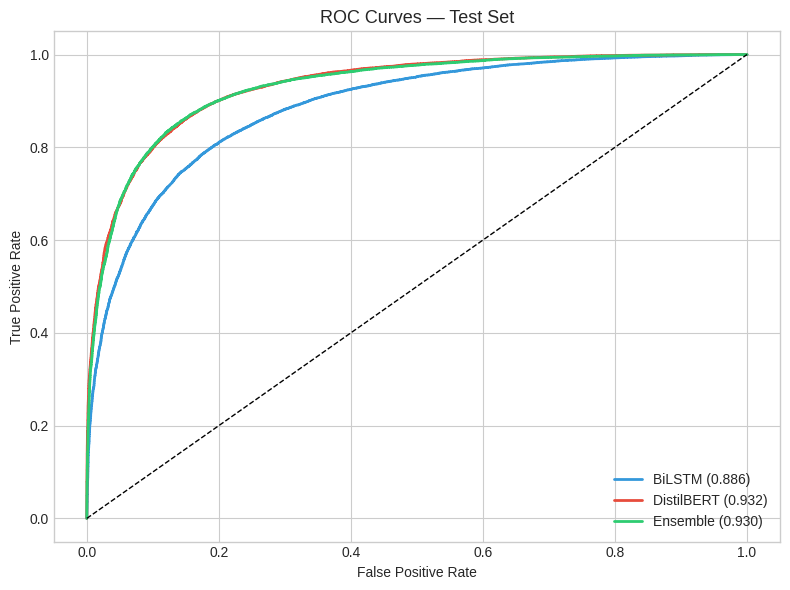

In [19]:
# ── 8.3  Visualizations ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Final Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrices
for ax, preds, title in zip(
    axes,
    [lstm_preds, bert_preds, ensemble_preds],
    ['BiLSTM', 'DistilBERT', 'Ensemble']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{title}\nAcc: {acc:.4f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}confusion_matrices.png', dpi=150)
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for probs, label, color in [
    (lstm_probs,     f'BiLSTM ({lstm_auc:.3f})',     '#3498db'),
    (bert_probs,     f'DistilBERT ({bert_auc:.3f})', '#e74c3c'),
    (ensemble_probs, f'Ensemble ({ensemble_auc:.3f})', '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curves — Test Set', fontsize=13)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}roc_curves.png', dpi=150)
plt.show()

## 9. Attention Visualization (Explainability)

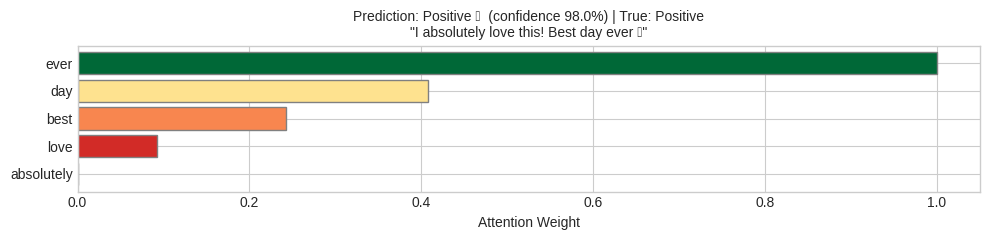

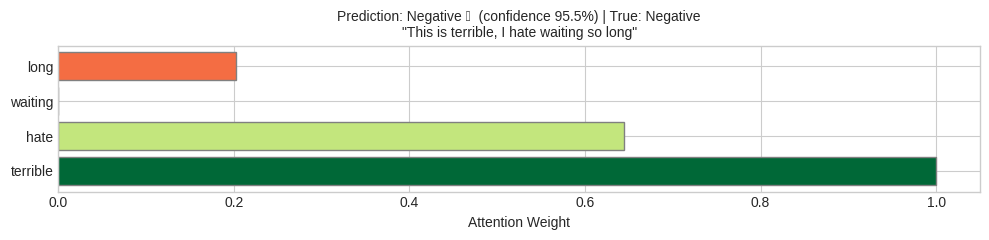

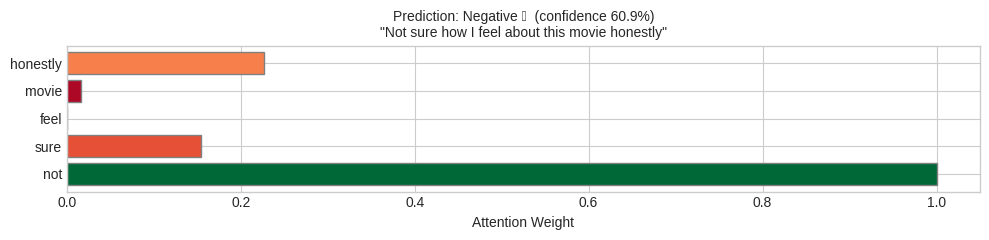

In [20]:
def explain_with_attention(text, true_label=None):
    lstm_model.eval()
    cleaned = preprocess(text)
    ids     = encode(cleaned, vocab, CFG.MAX_LEN_LSTM)
    if not ids: ids = [1]
    tensor  = torch.tensor(ids).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, attn_w = lstm_model(tensor)
        prob = torch.softmax(logits, dim=-1)[0, 1].item()

    words   = cleaned.split()[:CFG.MAX_LEN_LSTM]
    weights = attn_w.squeeze().cpu().numpy()[:len(words)]
    if len(words) == 0:
        print('No tokens after preprocessing — skipping visualization.')
        return
    w_range = weights.max() - weights.min()
    weights = (weights - weights.min()) / (w_range if w_range > 1e-6 else 1.0)

    pred_label = 'Positive 😊' if prob > 0.5 else 'Negative 😞'
    conf       = prob if prob > 0.5 else 1 - prob

    fig, ax = plt.subplots(figsize=(max(10, len(words) * 0.6), 2.5))
    colors  = plt.cm.RdYlGn(weights)
    bars    = ax.barh(range(len(words)), weights, color=colors, edgecolor='grey')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_xlabel('Attention Weight')
    title = f'Prediction: {pred_label}  (confidence {conf:.1%})'
    if true_label is not None:
        title += f' | True: {"Positive" if true_label else "Negative"}'
    ax.set_title(f'{title}\n"{text}"', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{CFG.SAVE_DIR}attention_viz.png', dpi=150)
    plt.show()


# Demo predictions
examples = [
    ("I absolutely love this! Best day ever 😊", 1),
    ("This is terrible, I hate waiting so long", 0),
    ("Not sure how I feel about this movie honestly", None),
]
for text, label in examples:
    explain_with_attention(text, label)

## 10. Inference Pipeline

In [21]:
class SentimentPipeline:
    """Production-ready ensemble inference pipeline."""

    def __init__(self, lstm_model, bert_model, vocab, tokenizer,
                 bert_weight=CFG.BERT_WEIGHT, lstm_weight=CFG.LSTM_WEIGHT):
        self.lstm      = lstm_model.eval()
        self.bert      = bert_model.eval()
        self.vocab     = vocab
        self.tokenizer = tokenizer
        self.bw        = bert_weight
        self.lw        = lstm_weight

    @torch.no_grad()
    def predict(self, texts: list[str]) -> list[dict]:
        results = []

        # LSTM predictions
        lstm_probs_batch = []
        for text in texts:
            cleaned = preprocess(text)
            ids = encode(cleaned, self.vocab, CFG.MAX_LEN_LSTM) or [1]
            x   = torch.tensor(ids).unsqueeze(0).to(DEVICE)
            logits, _ = self.lstm(x)
            lstm_probs_batch.append(F.softmax(logits, dim=-1)[0, 1].item())

        # BERT predictions
        light = [light_clean(t) for t in texts]
        enc   = self.tokenizer(light, truncation=True, padding=True,
                               max_length=CFG.MAX_LEN_BERT, return_tensors='pt')
        out   = self.bert(enc['input_ids'].to(DEVICE),
                          attention_mask=enc['attention_mask'].to(DEVICE))
        bert_probs_batch = F.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()

        for i, text in enumerate(texts):
            ensemble = self.bw * bert_probs_batch[i] + self.lw * lstm_probs_batch[i]
            results.append({
                'text'      : text,
                'sentiment' : 'Positive' if ensemble >= 0.5 else 'Negative',
                'confidence': float(max(ensemble, 1 - ensemble)),
                'prob_pos'  : float(ensemble),
                'lstm_prob' : float(lstm_probs_batch[i]),
                'bert_prob' : float(bert_probs_batch[i]),
            })
        return results


pipeline = SentimentPipeline(lstm_model, bert_model, vocab, bert_tokenizer)

test_tweets = [
    "Just got my new phone and it's amazing!",
    "Traffic was absolutely horrible today",
    "The weather is okay I guess",
    "I can't believe how good this concert was!",
    "Not happy with the service at all",
]
predictions = pipeline.predict(test_tweets)

col1, col2, col3, col4, col5 = "Tweet", "Sentiment", "Confidence", "BERT", "LSTM"
print(f"{col1:<48} {col2:<12} {col3:<12} {col4:<8} {col5}")
print('-' * 90)
for p in predictions:
    print(f"{p['text'][:45]:<48} {p['sentiment']:<12} {p['confidence']:.1%}{'':5} "
          f"{p['bert_prob']:.3f}  {p['lstm_prob']:.3f}")

Tweet                                            Sentiment    Confidence   BERT     LSTM
------------------------------------------------------------------------------------------
Just got my new phone and it's amazing!          Positive     99.6%      0.998  0.991
Traffic was absolutely horrible today            Negative     98.1%      0.007  0.041
The weather is okay I guess                      Positive     71.0%      0.874  0.404
I can't believe how good this concert was!       Positive     71.7%      0.926  0.328
Not happy with the service at all                Negative     98.3%      0.001  0.045


## 11. Save All Artifacts

In [22]:
import json

# Save BiLSTM
torch.save({
    'model_state_dict'    : lstm_model.state_dict(),
    'vocab'               : vocab,
    'max_len'             : CFG.MAX_LEN_LSTM,
    'hidden_dim'          : CFG.HIDDEN_DIM,
    'emb_dim'             : CFG.EMB_DIM,
    'num_layers'          : CFG.NUM_LAYERS,
    'val_accuracy'        : best_val_acc_lstm,
}, f'{CFG.SAVE_DIR}bilstm_final.pth')

# Save DistilBERT
bert_model.save_pretrained(f'{CFG.SAVE_DIR}distilbert_final/')
bert_tokenizer.save_pretrained(f'{CFG.SAVE_DIR}distilbert_final/')

# Save metrics summary
metrics = {
    'BiLSTM'    : {'accuracy': lstm_acc,     'auc': lstm_auc},
    'DistilBERT': {'accuracy': bert_acc,     'auc': bert_auc},
    'Ensemble'  : {'accuracy': ensemble_acc, 'auc': ensemble_auc},
}
with open(f'{CFG.SAVE_DIR}metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('All artifacts saved ✓')
print('\n🎯 Final Results:')
for model_name, m in metrics.items():
    print(f"  {model_name:<12}: Acc {m['accuracy']:.4f}  AUC {m['auc']:.4f}")

All artifacts saved ✓

🎯 Final Results:
  BiLSTM      : Acc 0.8053  AUC 0.8864
  DistilBERT  : Acc 0.8550  AUC 0.9316
  Ensemble    : Acc 0.8567  AUC 0.9302
